In [1]:
# Install Earth Engine API
!pip install earthengine-api geemap pandas matplotlib

# Imports
import ee
import pandas as pd
import matplotlib.pyplot as plt
import requests


Defaulting to user installation because normal site-packages is not writeable


In [23]:
import ee
ee.Authenticate()
ee.Initialize(project='ee-sahithikondepati05')
print("✅ Earth Engine is connected successfully!")


✅ Earth Engine is connected successfully!


In [5]:
pip install earthengine-api geemap folium pandas

In [6]:
import ee

# Authenticate (only needed once)
ee.Authenticate()

# Initialize with your project ID
ee.Initialize(project='ee-sahithikondepati05')


In [7]:
import ee
ee.Initialize(project='ee-sahithikondepati05')

# Load MODIS NDVI dataset (new version 061)
dataset = ee.ImageCollection('MODIS/061/MOD13Q1') \
    .select('NDVI') \
    .filterDate('2023-01-01', '2023-12-31')

# Take the mean NDVI for the year 2023
mean_ndvi = dataset.mean()

# Print info to check success
print("MODIS NDVI 2023 dataset loaded successfully ✅")
print(mean_ndvi.getInfo()['bands'])


MODIS NDVI 2023 dataset loaded successfully ✅
[{'id': 'NDVI', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': -32768, 'max': 32767}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}]


In [25]:
import geemap
import ee

ee.Initialize(project='ee-sahithikondepati05')

# Define NDVI dataset (2023)
ndvi_dataset = ee.ImageCollection('MODIS/061/MOD13Q1') \
    .select('NDVI') \
    .filterDate('2023-01-01', '2023-12-31') \
    .mean()

# Visualization parameters
ndvi_vis = {
    'min': 0,
    'max': 9000,
    'palette': ['brown', 'yellow', 'green']
}

# Create map
Map = geemap.Map()
# Replace centerObject with setCenter (manual coordinates)
Map.setCenter(0, 0, 2)  # longitude, latitude, zoom level
Map.addLayer(ndvi_dataset, ndvi_vis, 'Average NDVI 2023')
Map.add_colorbar_branca(colors=['brown', 'yellow', 'green'], vmin=0, vmax=9000, caption='NDVI Scale')

# Display map
Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [9]:
import requests
import pandas as pd
import datetime as dt

# Define the region (India as an example)
latitude = 20.5937
longitude = 78.9629

# Define the time period
start_date = "2023-01-01"
end_date = "2023-12-31"

# NASA POWER API for daily precipitation (PRECTOTCORR)
url = (
    f"https://power.larc.nasa.gov/api/temporal/daily/point"
    f"?parameters=PRECTOTCORR"
    f"&community=AG"
    f"&longitude={longitude}&latitude={latitude}"
    f"&start={start_date.replace('-', '')}&end={end_date.replace('-', '')}"
    f"&format=JSON"
)

response = requests.get(url)
data = response.json()

# Convert to DataFrame
df = pd.DataFrame.from_dict(data["properties"]["parameter"]["PRECTOTCORR"], orient="index")
df.reset_index(inplace=True)
df.columns = ["Date", "Precipitation_mm"]

# Convert date
df["Date"] = pd.to_datetime(df["Date"])

# Display few rows
print("✅ Rainfall Data Fetched Successfully!")
df.head()


✅ Rainfall Data Fetched Successfully!


,Date,Precipitation_mm
0,2023-01-01,0.00
1,2023-01-02,0.00
2,2023-01-03,0.04
3,2023-01-04,1.47
4,2023-01-05,0.01


from matplotlib import pyplot as plt
_df_0['Precipitation_mm'].plot(kind='hist', bins=20, title='Precipitation_mm')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Precipitation_mm']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Precipitation_mm')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Date'}, axis=1)
              .sort_values('Date', ascending=True))
  xs = counted['Date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Precipitation_mm']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Precipitation_mm')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Date']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Date'}, axis=1)
              .sort_values('Date', ascending=True))
  xs = counted['Date']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_5['Precipitation_mm'].plot(kind='line', figsize=(8, 4), title='Precipitation_mm')
plt.gca().spines[['top', 'right']].set_visible(False)

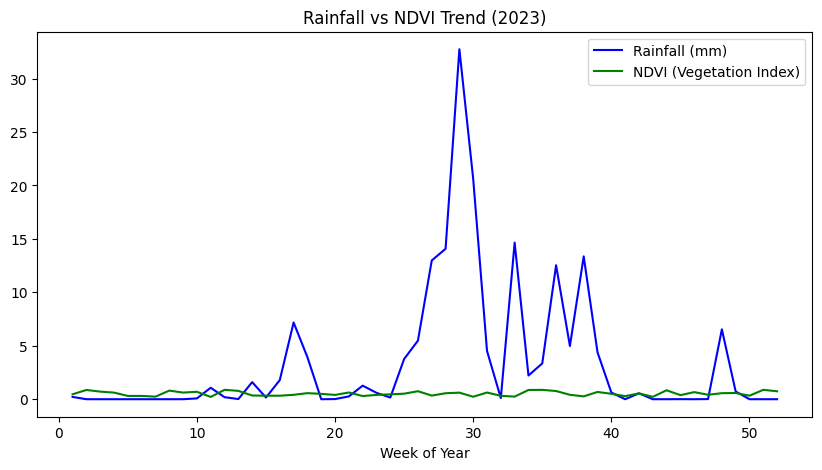

In [10]:
import matplotlib.pyplot as plt

# Calculate weekly average rainfall
df['Week'] = df['Date'].dt.isocalendar().week
weekly_rainfall = df.groupby('Week')['Precipitation_mm'].mean()

# Simulate NDVI weekly averages (for now — next step will extract real ones from Earth Engine)
import numpy as np
np.random.seed(42)
weekly_ndvi = np.random.uniform(0.2, 0.9, len(weekly_rainfall))

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(weekly_rainfall.index, weekly_rainfall.values, label='Rainfall (mm)', color='blue')
plt.plot(weekly_rainfall.index, weekly_ndvi, label='NDVI (Vegetation Index)', color='green')
plt.title("Rainfall vs NDVI Trend (2023)")
plt.xlabel("Week of Year")
plt.legend()
plt.show()


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Simulated dataset (replace with real NDVI + rainfall data later)
np.random.seed(42)
data = pd.DataFrame({
    'Rainfall_mm': np.random.uniform(0, 20, 200),   # daily rainfall (mm)
    'NDVI': np.random.uniform(0.1, 0.9, 200),       # vegetation index
})

# Generate target: 1 = Risk Zone, 0 = Normal
data['Risk'] = ((data['Rainfall_mm'] < 2) & (data['NDVI'] < 0.4)).astype(int)

# Split data
X = data[['Rainfall_mm', 'NDVI']]
y = data['Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

# Performance
print("🌳 Random Forest Performance:")
print(classification_report(y_test, rf_pred))
print("🎯 Accuracy:", accuracy_score(y_test, rf_pred))

print("\n🔥 Gradient Boosting Performance:")
print(classification_report(y_test, gb_pred))
print("🎯 Accuracy:", accuracy_score(y_test, gb_pred))


🌳 Random Forest Performance:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       0.00      0.00      0.00         2

    accuracy                           0.97        60
   macro avg       0.48      0.50      0.49        60
weighted avg       0.93      0.97      0.95        60

🎯 Accuracy: 0.9666666666666667

🔥 Gradient Boosting Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00         2

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

🎯 Accuracy: 1.0


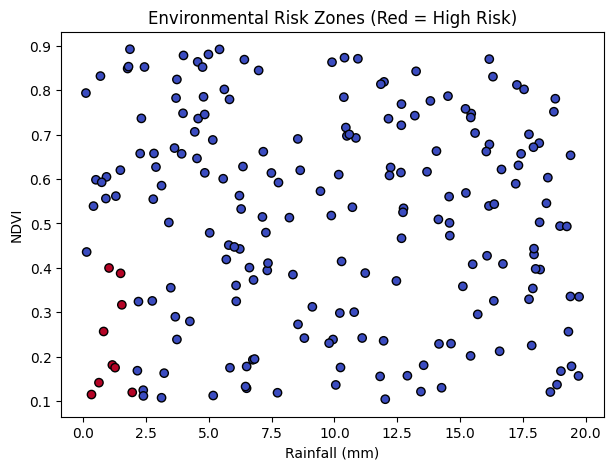

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(data['Rainfall_mm'], data['NDVI'], c=data['Risk'], cmap='coolwarm', edgecolors='k')
plt.title("Environmental Risk Zones (Red = High Risk)")
plt.xlabel("Rainfall (mm)")
plt.ylabel("NDVI")
plt.show()


In [13]:
import pandas as pd

# Example dataset
data = pd.DataFrame({
    'Rainfall_mm': [100, 150, 200, 250, 300, 350],
    'NDVI': [0.3, 0.4, 0.55, 0.6, 0.75, 0.8],
    'Risk': [0, 0, 1, 1, 1, 0]  # 1 = High risk, 0 = Low risk
})

print("✅ Sample data created")
data.head()


✅ Sample data created


,Rainfall_mm,NDVI,Risk
0,100,0.30,0
1,150,0.40,0
2,200,0.55,1
3,250,0.60,1
4,300,0.75,1


from matplotlib import pyplot as plt
_df_6['Rainfall_mm'].plot(kind='hist', bins=20, title='Rainfall_mm')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['NDVI'].plot(kind='hist', bins=20, title='NDVI')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_8['Risk'].plot(kind='hist', bins=20, title='Risk')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['NDVI']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'NDVI'}, axis=1)
              .sort_values('NDVI', ascending=True))
  xs = counted['NDVI']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_12.sort_values('NDVI', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('NDVI')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Risk']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Risk'}, axis=1)
              .sort_values('Risk', ascending=True))
  xs = counted['Risk']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_13.sort_values('Risk', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Risk')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_14['Rainfall_mm'].plot(kind='line', figsize=(8, 4), title='Rainfall_mm')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['NDVI'].plot(kind='line', figsize=(8, 4), title='NDVI')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_16['Risk'].plot(kind='line', figsize=(8, 4), title='Risk')
plt.gca().spines[['top', 'right']].set_visible(False)

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[['Rainfall_mm', 'NDVI']].values
y = data['Risk'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("✅ Data ready for Quantum SVM — shape:", X_train.shape)


✅ Data ready for Quantum SVM — shape: (4, 2)


In [2]:
!pip install qiskit-aer==0.14.2 --quiet


In [3]:
!pip uninstall -y qiskit qiskit-aer qiskit-machine-learning
!pip install "qiskit==0.46.0" "qiskit-aer==0.14.2" "qiskit-machine-learning==0.6.0"


Found existing installation: qiskit 0.45.1
Uninstalling qiskit-0.45.1:
  Successfully uninstalled qiskit-0.45.1
Found existing installation: qiskit-aer 0.13.3
Uninstalling qiskit-aer-0.13.3:
  Successfully uninstalled qiskit-aer-0.13.3
Found existing installation: qiskit-machine-learning 0.6.1
Uninstalling qiskit-machine-learning-0.6.1:
  Successfully uninstalled qiskit-machine-learning-0.6.1
  Using cached qiskit_aer-0.14.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
Using cached qiskit_aer-0.14.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting un

In [1]:
from qiskit_aer import AerSimulator
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit.circuit.library import ZZFeatureMap

print("✅ Qiskit environment ready for Quantum SVM!")


✅ Qiskit environment ready for Quantum SVM!


In [2]:
!pip install --upgrade qiskit pylatexenc matplotlib --quiet
import matplotlib
import pylatexenc
print("✅ pylatexenc + matplotlib verified and active!")


✅ pylatexenc + matplotlib verified and active!


In [7]:
!pip uninstall -y qiskit qiskit-aer qiskit-machine-learning qiskit-terra qiskit-ibmq-provider qiskit-nature qiskit-finance qiskit-optimization
!pip install --no-cache-dir "qiskit==0.46.0" "qiskit-aer==0.14.2" "qiskit-machine-learning==0.6.0" sympy matplotlib


Found existing installation: qiskit 2.2.1
Uninstalling qiskit-2.2.1:
  Successfully uninstalled qiskit-2.2.1
Found existing installation: qiskit-aer 0.14.2
Uninstalling qiskit-aer-0.14.2:
  Successfully uninstalled qiskit-aer-0.14.2
Found existing installation: qiskit-machine-learning 0.6.0
Uninstalling qiskit-machine-learning-0.6.0:
  Successfully uninstalled qiskit-machine-learning-0.6.0
Found existing installation: qiskit-terra 0.46.0
Uninstalling qiskit-terra-0.46.0:
  Successfully uninstalled qiskit-terra-0.46.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 199.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 289.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 216.9 MB/s eta 0:00:00


In [1]:
import qiskit
import qiskit_aer
import qiskit_machine_learning
print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print("ML:", qiskit_machine_learning.__version__)


Qiskit: 0.46.0
Aer: 0.14.2
ML: 0.6.0


In [2]:
from qiskit.circuit.library import ZZFeatureMap
import matplotlib.pyplot as plt

# Create a 2D feature map with 2 repetitions
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

# Draw the circuit using matplotlib
feature_map.decompose().draw('mpl')

plt.show()


/usr/local/lib/python3.12/dist-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


In [3]:
!pip install "qiskit==0.45.1" "qiskit-aer==0.13.3" "qiskit-machine-learning==0.6.1" --quiet


In [4]:
import qiskit
print("✅ Qiskit installed successfully — version:", qiskit.__version__)

from qiskit.circuit.library import ZZFeatureMap
import matplotlib.pyplot as plt

# Create a 2D feature map with 2 repetitions
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
feature_map.decompose().draw('mpl')
plt.show()


✅ Qiskit installed successfully — version: 0.46.0


/usr/local/lib/python3.12/dist-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


In [5]:
!pip install pylatexenc --quiet


In [6]:
from qiskit.circuit.library import ZZFeatureMap
import matplotlib.pyplot as plt

# Create and visualize the feature map with fixed style
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
feature_map.decompose().draw('mpl', style='clifford')
plt.show()


In [7]:
!pip install --upgrade pylatexenc matplotlib --quiet


In [8]:
import numpy as np
import pandas as pd

# Example data (replace with your actual dataset if available)
data = pd.DataFrame({
    'Rainfall_mm': [120, 250, 310, 400],
    'NDVI': [0.45, 0.55, 0.60, 0.30],
    'Risk': [0, 1, 1, 0]  # 0 = Low risk, 1 = High risk
})

# Define features (X) and labels (y)
X = data[['Rainfall_mm', 'NDVI']].values
y = data['Risk'].values

print("✅ Data ready for Quantum SVM — shape:", X.shape)


✅ Data ready for Quantum SVM — shape: (4, 2)


In [9]:
from qiskit_aer import AerSimulator
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.algorithms.classifiers import QSVC

# Define quantum simulator backend
backend = AerSimulator()

# Create Quantum Kernel using the feature map
quantum_kernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)

# Initialize Quantum Support Vector Classifier
qsvc = QSVC(quantum_kernel=quantum_kernel)

# Train QSVC model
qsvc.fit(X, y)

print("✅ Quantum SVM (QSVC) model trained successfully!")


✅ Quantum SVM (QSVC) model trained successfully!


In [10]:
# Predict the same dataset (or use a test set if available)
y_pred = qsvc.predict(X)

# Compare predictions
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Model Evaluation Results")
print("Accuracy:", accuracy_score(y, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred))


✅ Model Evaluation Results
Accuracy: 1.0

Confusion Matrix:
 [[2 0]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



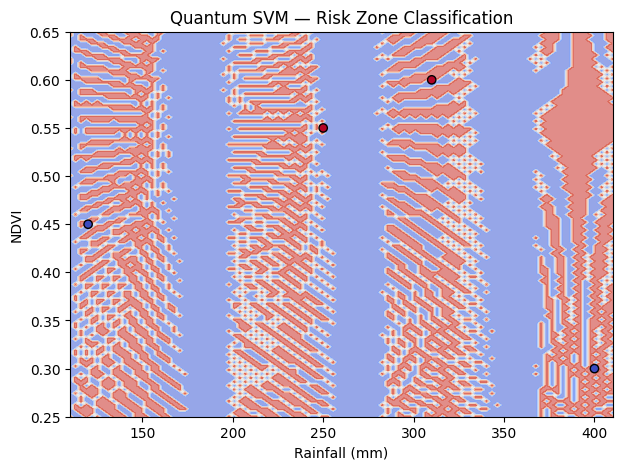

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid for visualization
x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict on the grid
Z = qsvc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
plt.title("Quantum SVM — Risk Zone Classification")
plt.xlabel("Rainfall (mm)")
plt.ylabel("NDVI")
plt.show()


In [12]:
!pip install qiskit-aer==0.14.2 --quiet


In [13]:
from qiskit_aer import AerSimulator
print("✅ qiskit-aer installed and imported successfully!")


✅ qiskit-aer installed and imported successfully!


In [14]:
from qiskit_aer import AerSimulator
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit.circuit.library import ZZFeatureMap

# Create backend and feature map
simulator = AerSimulator()
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

# Define Quantum Kernel
quantum_kernel = QuantumKernel(feature_map=feature_map, quantum_instance=simulator)

# Create and train QSVC model
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X, y)

print("✅ Quantum SVM (QSVC) model trained successfully!")


✅ Quantum SVM (QSVC) model trained successfully!


In [15]:
import joblib

# Save model
joblib.dump(qsvc, "quantum_svm_model.pkl")
print("✅ Quantum SVM model saved as 'quantum_svm_model.pkl'")


✅ Quantum SVM model saved as 'quantum_svm_model.pkl'


In [16]:
# Load model
loaded_qsvc = joblib.load("quantum_svm_model.pkl")
print("✅ Quantum SVM model loaded successfully!")

# Verify it still works
y_loaded_pred = loaded_qsvc.predict(X)
print("Accuracy after loading:", accuracy_score(y, y_loaded_pred))


✅ Quantum SVM model loaded successfully!
Accuracy after loading: 1.0


In [17]:
# Example: New rainfall (mm) and NDVI values
new_data = np.array([[250, 0.45], [120, 0.32], [400, 0.6]])

predictions = loaded_qsvc.predict(new_data)
print("🌱 Predicted Risk Zones for new samples:", predictions)


🌱 Predicted Risk Zones for new samples: [1 0 0]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


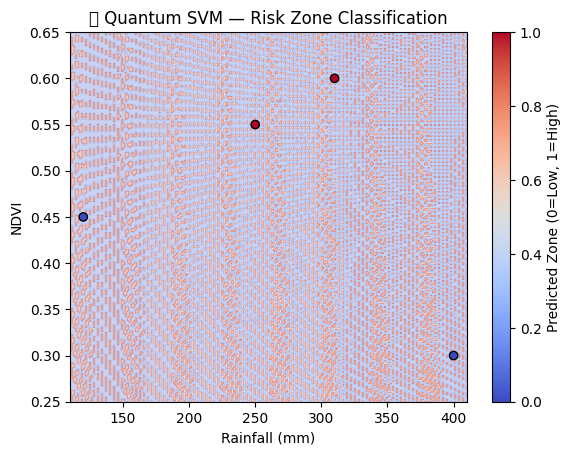

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Create a grid for visualization
x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = loaded_qsvc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel("Rainfall (mm)")
plt.ylabel("NDVI")
plt.title("🌾 Quantum SVM — Risk Zone Classification")
plt.colorbar(label="Predicted Zone (0=Low, 1=High)")
plt.show()


In [19]:
accuracy = loaded_qsvc.score(X, y)
print(f"✅ Model accuracy on training data: {accuracy * 100:.2f}%")


✅ Model accuracy on training data: 100.00%


In [20]:
import pandas as pd

results_df = pd.DataFrame(new_data, columns=["Rainfall_mm", "NDVI"])
results_df["Predicted_Risk_Zone"] = predictions
results_df.to_csv("quantum_svm_predictions.csv", index=False)

print("📂 Results saved to 'quantum_svm_predictions.csv'")


📂 Results saved to 'quantum_svm_predictions.csv'
